Using Colab cache for faster access to the 'wine-quality-dataset' dataset.
Path to dataset files: /kaggle/input/wine-quality-dataset
Dimensões originais: 1143 linhas e 13 colunas.

Contagem de valores nulos por coluna:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


 125 registros duplicados reais removidos para governança do pipeline.

 Distribuição da variável alvo (qualidade binária):


,count
quality_binary,
0,881
1,137


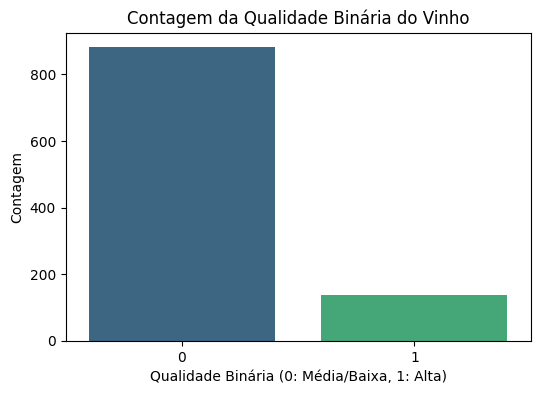


Visualização das primeiras linhas das variáveis prontas para os Modelos (Frente B):


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.510499,0.909227,-1.370507,-0.475125,-0.230739,-0.457043,-0.372294,0.574517,1.258719,-0.578153,-0.961563
1,-0.280676,1.892418,-1.370507,0.057517,0.223040,0.919349,0.624466,0.052448,-0.707068,0.138438,-0.596108
2,-0.280676,1.236957,-1.166564,-0.170758,0.099282,-0.063788,0.231803,0.156862,-0.326593,-0.040710,-0.596108
3,1.672822,-1.384886,1.484700,-0.475125,-0.251365,0.132839,0.413032,0.678931,-0.960718,-0.458721,-0.596108
4,-0.510499,0.690740,-1.370507,-0.551216,-0.251365,-0.260415,-0.191065,0.574517,1.258719,-0.578153,-0.961563


In [5]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

path = kagglehub.dataset_download("yasserh/wine-quality-dataset")
print("Path to dataset files:", path)

wine_path = os.path.join(path, 'WineQT.csv')
wine_df = pd.read_csv(wine_path)
print(f"Dimensões originais: {wine_df.shape[0]} linhas e {wine_df.shape[1]} colunas.\n")

# verificação de valores nulos
print("Contagem de valores nulos por coluna:")
display(wine_df.isnull().sum())

# remoção de duplicatas
features_para_checar = wine_df.drop(columns=['Id'], errors='ignore').columns
duplicated_count = wine_df.duplicated(subset=features_para_checar).sum()

if duplicated_count > 0:
    wine_df = wine_df.drop_duplicates(subset=features_para_checar)
    print(f" {duplicated_count} registros duplicados reais removidos para governança do pipeline.")

# vinho de alta qualidade: nota >= 7 | baixa/média: nota < 7
if 'quality_binary' not in wine_df.columns:
    wine_df['quality_binary'] = wine_df['quality'].apply(lambda x: 1 if x >= 7 else 0)

print("\n Distribuição da variável alvo (qualidade binária):")
display(wine_df['quality_binary'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='quality_binary', data=wine_df, hue='quality_binary', palette='viridis', legend=False)
plt.title('Contagem da Qualidade Binária do Vinho')
plt.xlabel('Qualidade Binária (0: Média/Baixa, 1: Alta)')
plt.ylabel('Contagem')
plt.show()

# separando as variáveis preditoras (x) do alvo binário (y)
# removemos 'quality' (alvo antigo), 'quality_binary' (alvo novo) e 'id' (não preditivo)
X = wine_df.drop(columns=['quality', 'quality_binary', 'Id'], errors='ignore')
y = wine_df['quality_binary']

# aplicando (média = 0, desvio padrão = 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("\nVisualização das primeiras linhas das variáveis prontas para os Modelos (Frente B):")
display(X_scaled_df.head())

!pip freeze > requirements.txt